In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import osmnx as ox
from utils_z import get_conn, run_sql, run_cmd
import os

### 1. 处理pbf并导入数据库

#### 1.1 通过城市名称获得city边界

CURRENT PROCESSING CITY: Hamburg, Germany
       display_name  osm_id  osm_type
0  Hamburg, Germany   62782  relation
crs: epsg:4326
geo type: ['MultiPolygon']


<Axes: >

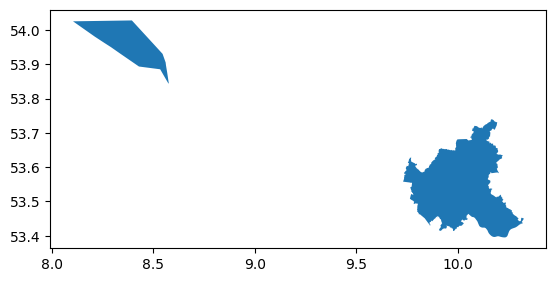

In [3]:
# 通过城市名称获得city边界
country_pbf_name = "hamburg-260412.osm.pbf"
pbf_filepath = f"E:\\2_data\\geofabrik_downloads\\{country_pbf_name}"

city_query_name = "Hamburg, Germany"

city = ox.geocode_to_gdf(city_query_name)
print("CURRENT PROCESSING CITY: " + city_query_name)
print(city[["display_name", "osm_id", "osm_type"]])

# 检查结果
print(f"crs: {city.crs}")  # 应该是 EPSG:4326
print(f"geo type: {city.geometry.type.values}")  # 应该是 MultiPolygon 或 Polygon
city.plot()

#### 1.2 通过城市边界裁剪 pbf 数据

In [4]:
# 保存为GeoJSON
city_name = city_query_name.split(",")[0].lower().strip()

bound_filename = city_name + "_boundary.geojson"
bound_filepath = "E:\\2_data\\block_data\\boundary\\" + bound_filename
city.to_file(bound_filepath, driver="GeoJSON")
print(city_name + " boundary has been saved")

hamburg boundary has been saved


#### 1.3 使用 osmium 从 pbf 中提取边界内的 OSM 数据

In [15]:
# 定义路径
output_filename = city_query_name.split(",")[0].lower().strip() + ".osm.pbf"
output_filepath = f"E:\\2_data\\block_data\\city_clip\\{output_filename}"

osmium_path = "E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe"
cmd = f'"{osmium_path}" extract --strategy=smart --polygon {bound_filepath} {pbf_filepath} -o {output_filepath} --overwrite'
run_cmd(cmd)

CompletedProcess(args='"E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe" extract --strategy=smart --polygon E:\\2_data\\block_data\\boundary\\hamburg_boundary.geojson E:\\2_data\\geofabrik_downloads\\hamburg-260412.osm.pbf -o E:\\2_data\\block_data\\city_clip\\hamburg.osm.pbf --overwrite', returncode=0, stdout='', stderr='')

#### 1.4 使用osmium分离出路网

In [17]:
output_road_path = f"E:\\2_data\\block_data\\city_clip\\{city_name + "_road.osm.pbf"}"

cmd = f'"{osmium_path}" tags-filter {output_filepath} w/highway=motorway,motorway_link,trunk,trunk_link,primary,primary_link,secondary,secondary_link,tertiary,tertiary_link,residential,unclassified -o {output_road_path} --overwrite'
run_cmd(cmd)

CompletedProcess(args='"E:\\0_python_envs\\urbanCode\\Library\\bin\\osmium.exe" tags-filter E:\\2_data\\block_data\\city_clip\\hamburg.osm.pbf w/highway=motorway,motorway_link,trunk,trunk_link,primary,primary_link,secondary,secondary_link,tertiary,tertiary_link,residential,unclassified -o E:\\2_data\\block_data\\city_clip\\hamburg_road.osm.pbf --overwrite', returncode=0, stdout='', stderr='')

#### 1.5使用 osm2pgsql 将裁剪分离后的路网数据导入 PostgreSQL 数据库

In [35]:
osm2pgsql_path = "osm2pgsql"
osm2pgsql_default_style = "D:\\workSoftware\\PostgreSQL_Addon\\osm2pgsql-bin\\default.style"

os.environ["PGPASSWORD"] = "we6666"

cmd = f'{osm2pgsql_path} -c -d Test20260413 -U postgres -H localhost --slim -C 4000 --style={osm2pgsql_default_style} {output_road_path}'

run_cmd(cmd)

2026-04-14 10:00:07  osm2pgsql version 2.2.0 (2.2.0)
2026-04-14 10:00:07  Database version: 18.1
2026-04-14 10:00:07  PostGIS version: 3.6
2026-04-14 10:00:07  WARNING: The pgsql (default) output is deprecated. For details see https://osm2pgsql.org/doc/faq.html#the-pgsql-output-is-deprecated-what-does-that-mean
2026-04-14 10:00:07  Initializing properties table '"public"."osm2pgsql_properties"'.
2026-04-14 10:00:07  Storing properties to table '"public"."osm2pgsql_properties"'.
2026-04-14 10:00:07  Setting up table 'planet_osm_point'
2026-04-14 10:00:08  Setting up table 'planet_osm_line'
2026-04-14 10:00:08  Setting up table 'planet_osm_polygon'
2026-04-14 10:00:08  Setting up table 'planet_osm_roads'

Processing: Node(160k 160.0k/s) Way(0k 0.00k/s) Relation(0 0.0/s)
                                                                                          
2026-04-14 10:00:10  Reading input files done in 2s.
2026-04-14 10:00:10    Processed 191140 nodes in 1s - 191k/s
2026-04-14 10:00

CompletedProcess(args='osm2pgsql -c -d Test20260413 -U postgres -H localhost --slim -C 4000 --style=D:\\workSoftware\\PostgreSQL_Addon\\osm2pgsql-bin\\default.style E:\\2_data\\block_data\\city_clip\\hamburg_road.osm.pbf', returncode=0, stdout='', stderr='2026-04-14 10:00:07  osm2pgsql version 2.2.0 (2.2.0)\n2026-04-14 10:00:07  Database version: 18.1\n2026-04-14 10:00:07  PostGIS version: 3.6\n2026-04-14 10:00:07  WARNING: The pgsql (default) output is deprecated. For details see https://osm2pgsql.org/doc/faq.html#the-pgsql-output-is-deprecated-what-does-that-mean\n2026-04-14 10:00:07  Initializing properties table \'"public"."osm2pgsql_properties"\'.\n2026-04-14 10:00:07  Storing properties to table \'"public"."osm2pgsql_properties"\'.\n2026-04-14 10:00:07  Setting up table \'planet_osm_point\'\n2026-04-14 10:00:08  Setting up table \'planet_osm_line\'\n2026-04-14 10:00:08  Setting up table \'planet_osm_polygon\'\n2026-04-14 10:00:08  Setting up table \'planet_osm_roads\'\n\nProcessi

#### 1.6 使用 SQL 查询确认数据已成功导入，并检查坐标系

In [47]:
conn = get_conn("Test20260413", "postgres", "we6666", "localhost", "5432")

# 第一步：确认坐标系
sql_draw_check = "SELECT ST_SRID(way) FROM planet_osm_line LIMIT 1;"
result = run_sql(sql_draw_check, fetch=True, conn=conn)
print(f"当前坐标系SRID：{result[0][0]}")

当前坐标系SRID：3857


### 2. 使用 PostGIS 切割 Block

#### 2.1 使用 ST_Polygonize 切割 Block
* 编码25832计算面积
* noded道路交叉点
* 面积筛选大于1000
* 创建新表

In [49]:
sql_create_blocks = """
CREATE TABLE IF NOT EXISTS blocks AS
WITH
roads AS (
    SELECT ST_Transform(way, 25832) AS geom
    FROM planet_osm_line
    WHERE highway IN (
        'motorway', 'motorway_link',
        'trunk', 'trunk_link',
        'primary', 'primary_link',
        'secondary', 'secondary_link',
        'tertiary', 'tertiary_link',
        'residential', 'unclassified'
    )
),
noded AS (
    SELECT ST_Node(ST_Collect(geom)) AS geom FROM roads
),
polygonized AS (
    SELECT (ST_Dump(ST_Polygonize(geom))).geom AS geom FROM noded
)
SELECT
    ROW_NUMBER() OVER () AS block_id,
    geom
FROM polygonized
WHERE ST_Area(geom) > 1000;
"""

run_sql(sql_create_blocks, conn=conn)
print("Block表创建完成")

# 第三步：添加主键和空间索引
run_sql("ALTER TABLE blocks ADD PRIMARY KEY (block_id);", conn=conn)
run_sql("CREATE INDEX blocks_geom_idx ON blocks USING GIST (geom);", conn=conn)
print("索引创建完成")

Block表创建完成
索引创建完成


In [50]:
result = run_sql("SELECT COUNT(*) FROM blocks;", fetch=True, conn=conn)
print(f"Block总数：{result[0][0]}")

Block总数：6538


#### 2.2 面积检查

In [55]:
# 检查Block的面积分布
result = run_sql("""
SELECT
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE ST_Area(geom) > 200000) AS oversized,
    MIN(ST_Area(geom)) AS min_area,
    MAX(ST_Area(geom)) AS max_area,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY ST_Area(geom)) AS median_area,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY ST_Area(geom)) AS p95_area
FROM blocks;
""", fetch=True,conn=conn)

print(f"总Block数：{result[0][0]}")
print(f"超大Block数（>20公顷）：{result[0][1]}")
print(f"最小面积：{result[0][2]:.0f}㎡")
print(f"最大面积：{result[0][3]:.0f}㎡")
print(f"中位数面积：{result[0][4]:.0f}㎡")
print(f"95分位面积：{result[0][5]:.0f}㎡")

总Block数：6538
超大Block数（>20公顷）：441
最小面积：1001㎡
最大面积：13662943㎡
中位数面积：22987㎡
95分位面积：271639㎡


In [56]:
result = run_sql("""
SELECT
    CASE
        WHEN ST_Area(geom) < 5000 THEN '< 0.5公顷'
        WHEN ST_Area(geom) < 10000 THEN '0.5–1公顷'
        WHEN ST_Area(geom) < 50000 THEN '1–5公顷'
        WHEN ST_Area(geom) < 100000 THEN '5–10公顷'
        WHEN ST_Area(geom) < 200000 THEN '10–20公顷'
        WHEN ST_Area(geom) < 500000 THEN '20–50公顷'
        WHEN ST_Area(geom) < 1000000 THEN '50–100公顷'
        ELSE '> 100公顷'
    END AS area_range,
    COUNT(*) AS count
FROM blocks
GROUP BY area_range
ORDER BY MIN(ST_Area(geom));
""", fetch=True, conn=conn)

for row in result:
    print(f"{row[0]}: {row[1]}个")

< 0.5公顷: 1139个
0.5–1公顷: 735个
1–5公顷: 2964个
5–10公顷: 852个
10–20公顷: 407个
20–50公顷: 273个
50–100公顷: 83个
> 100公顷: 85个


#### 2.3 绘制检查

In [51]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
import py5

In [52]:
sql_draw_check = """
      SELECT row_number() OVER () AS rid, geom
      FROM blocks
      ORDER BY geom; \
      """
gdf = gpd.read_postgis(sql_draw_check, conn, geom_col="geom", crs="EPSG:3857")
blocks_draw = list(gdf.geometry)

print(f"Loaded {len(blocks_draw)} blocks")

E:\0_python_envs\urbanCode\Lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Loaded 6538 blocks


In [53]:
def all_polygons(g):
    """把 MultiPolygon 统一展开成 Polygon 列表"""
    if isinstance(g, Polygon):
        return [g]
    elif isinstance(g, MultiPolygon):
        return list(g.geoms)
    return []

def draw_block(poly):
    """把 polygon 缩放并居中到屏幕绘制"""

    # 窗口大小
    W, H = py5.width, py5.height

    minx, miny, maxx, maxy = poly.bounds
    cw = maxx - minx
    ch = maxy - miny

    # 留一点边距
    margin = 0.15
    scale = min((W * (1 - margin)) / cw, (H * (1 - margin)) / ch)

    # 居中偏移量
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    py5.push_matrix()
    py5.translate(W / 2, H / 2)
    py5.scale(scale, -scale)   # y 轴反向，方便直观
    py5.translate(-cx, -cy)

    py5.fill(210)
    py5.stroke(0)

    for p in all_polygons(poly):
        coords = list(p.exterior.coords)

        py5.begin_shape()
        for x, y in coords:
            py5.vertex(x, y)
        py5.end_shape(py5.CLOSE)

    py5.pop_matrix()

In [ ]:
# py5显示

current = 0

def setup():
    py5.size(900, 700)
    py5.text_size(16)
    py5.text_align(py5.CENTER, py5.CENTER)


def draw():
    py5.background(255)

    global current
    b = blocks_draw[current]
    area = b.area   # m²（EPSG:3857）

    draw_block(b)

    py5.fill(0)
    py5.text(
        f"Block {current+1}/{len(blocks_draw)} — Area: {area:,.0f} m²\nPress 1 = next, q = quit",
        py5.width/2,
        30
    )


def key_pressed():
    global current

    if py5.key == '1':
        current = (current + 1) % len(blocks_draw)

    if py5.key == 'q':
        py5.exit_sketch()


py5.run_sketch()

### 3

In [57]:
print(city.total_bounds)

[ 8.1044993 53.3951118 10.3252805 54.02765  ]
